In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


from torchvision.transforms import RandomRotation, RandomHorizontalFlip, ColorJitter

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define dataset path
dataset_path = "/content/drive/MyDrive/image with free"  # Update this path

Using device: cuda


In [3]:
# Import required libraries
import torchvision.transforms as transforms

# Define augmentations
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Print to verify it works
print("Augmentation pipeline defined successfully!")


Augmentation pipeline defined successfully!


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import defaultdict

# -------------------------------
# 1. Define Transforms
# -------------------------------

# Transform برای Validation / Test
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Augmentation فقط برای Train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------------
# 2. Load dataset (initial transform)
# -------------------------------
dataset_path = "/content/drive/MyDrive/image with free"
dataset = datasets.ImageFolder(root=dataset_path, transform=base_transform)

# -------------------------------
# 3. Stratified split
# -------------------------------
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

class_indices = defaultdict(list)

# جمع کردن اندیس‌های هر کلاس
for idx, (_, label) in enumerate(dataset):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []

# تقسیم برای هر کلاس
for cls, indices in class_indices.items():
    np.random.shuffle(indices)
    n_total = len(indices)

    n_test = max(1, int(test_ratio * n_total))
    remaining = n_total - n_test

    n_train = int(train_ratio / (train_ratio + val_ratio) * remaining)
    n_val = remaining - n_train

    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val : n_train + n_val + n_test])

# -------------------------------
# 4. Create subsets
# -------------------------------
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# -------------------------------
# 5. Assign transforms separately
# -------------------------------
# فقط Train → augmentation
train_dataset.dataset.transform = train_transform

# Val & Test → بدون augmentation
val_dataset.dataset.transform = base_transform
test_dataset.dataset.transform = base_transform

# -------------------------------
# 6. DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("🔥 Stratified split + augmentation DONE!")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


🔥 Stratified split + augmentation DONE!
Train samples: 8784
Val samples: 1888
Test samples: 1879


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# -------------------------------------------------
# Device
# -------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# Load pretrained AlexNet
# -------------------------------------------------
model = models.alexnet(weights="IMAGENET1K_V1")

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# -------------------------------------------------
# Modify classifier (no LogSoftmax — CORRECT)
# -------------------------------------------------
num_classes = 10

model.classifier[6] = nn.Sequential(
    nn.Linear(model.classifier[6].in_features, 1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)   # logits output
)

model = model.to(device)

# -------------------------------------------------
# Loss Function (correct for logits)
# -------------------------------------------------
class_weights = torch.tensor([1,2,1.5,0.8,1.2,1.8,1,0.9,1.3,2.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# -------------------------------------------------
# Optimizer
# -------------------------------------------------
optimizer = optim.SGD([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], momentum=0.9, weight_decay=1e-4)

# -------------------------------------------------
# Scheduler
# -------------------------------------------------
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("✅ AlexNet model, optimizer, loss & scheduler are ready!")


Using device: cuda
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 188MB/s]


✅ AlexNet model, optimizer, loss & scheduler are ready!


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import defaultdict
import numpy as np
import os

# -------------------------------
# 1. Device
# -------------------------------
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# 2. Transforms
# -------------------------------
# Base transform (Val/Test)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Augmentation for Train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------
# 3. Load dataset
# -------------------------------
dataset_path = "/content/drive/MyDrive/image with free"
dataset = datasets.ImageFolder(root=dataset_path, transform=base_transform)

# -------------------------------
# 4. Stratified Split
# -------------------------------
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(dataset):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []

for cls, indices in class_indices.items():
    np.random.shuffle(indices)
    n_total = len(indices)
    n_test = max(1, int(test_ratio * n_total))
    remaining = n_total - n_test
    n_train = int(train_ratio / (train_ratio + val_ratio) * remaining)
    n_val = remaining - n_train

    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val:n_train + n_val + n_test])

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = base_transform
test_dataset.dataset.transform = base_transform

# -------------------------------
# 5. DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(" Data ready: Train =", len(train_dataset), "Val =", len(val_dataset), "Test =", len(test_dataset))

# -------------------------------
# 6. Load pretrained AlexNet
# -------------------------------
model = models.alexnet(weights="IMAGENET1K_V1")

# Freeze feature extractor
for p in model.features.parameters():
    p.requires_grad = False

# Move model to device BEFORE computing in_features
model = model.to(device)

# Automatically compute in_features
with torch.no_grad():
    sample = torch.zeros(1, 3, 224, 224).to(device)
    features_out = model.features(sample)
    in_features = features_out.view(1, -1).size(1)
print("Classifier in_features:", in_features)

# Modify classifier
num_classes = 10
model.classifier = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.GroupNorm(32, 1024),
    nn.Dropout(0.5),

    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.GroupNorm(32, 512),
    nn.Dropout(0.5),

    nn.Linear(512, num_classes)
)

# ---- IMPORTANT: move model again so new classifier's params live on device ----
model = model.to(device)

# -------------------------------
# 7. Loss, Optimizer, Scheduler
# -------------------------------
class_weights = torch.tensor([1,2,1.5,0.8,1.2,1.8,1,0.9,1.3,2.5], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

# -------------------------------
# 8. Checkpoint
# -------------------------------
checkpoint_path = "/content/drive/MyDrive/checkpoint_alexnet.pth"
start_epoch = 0
best_val_accuracy = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_accuracy = checkpoint["best_val_accuracy"]
    print(f" Resumed from epoch {start_epoch}, best_val_accuracy = {best_val_accuracy:.2f}%")
else:
    print("Starting from scratch...")

# -------------------------------
# 9. AMP setup
# -------------------------------
scaler = torch.amp.GradScaler()

# -------------------------------
# 10. Training Loop
# -------------------------------
num_epochs = 50

for epoch in range(start_epoch, num_epochs):
    print(f"\n🔵 Epoch {epoch+1}/{num_epochs}")

    # Training
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = 100 * correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = 100 * correct_val / total_val
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Train Loss={train_loss/len(train_loader):.4f}, Train Acc={train_acc:.2f}%, Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_alexnet_model.pth")
        print(" Best model updated!")

    # Save checkpoint
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_accuracy": best_val_accuracy
    }, checkpoint_path)
    print("💾 Checkpoint saved.")


Using device: cuda
🔥 Data ready: Train = 8784 Val = 1888 Test = 1879
Classifier in_features: 9216
Starting from scratch...

🔵 Epoch 1/50
Train Loss=0.7160, Train Acc=74.68%, Val Loss=0.4192, Val Acc=86.18%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 2/50
Train Loss=0.3854, Train Acc=86.38%, Val Loss=0.4198, Val Acc=86.33%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 3/50
Train Loss=0.2803, Train Acc=89.80%, Val Loss=0.4282, Val Acc=85.65%
💾 Checkpoint saved.

🔵 Epoch 4/50
Train Loss=0.2296, Train Acc=91.60%, Val Loss=0.3520, Val Acc=89.94%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 5/50
Train Loss=0.1781, Train Acc=93.53%, Val Loss=0.3750, Val Acc=89.41%
💾 Checkpoint saved.

🔵 Epoch 6/50
Train Loss=0.1473, Train Acc=94.46%, Val Loss=0.3872, Val Acc=89.35%
💾 Checkpoint saved.

🔵 Epoch 7/50
Train Loss=0.1298, Train Acc=95.28%, Val Loss=0.3650, Val Acc=90.84%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 8/50
Train Loss=0.1068, Train Acc=96.20%, Val Loss=0.3706, 

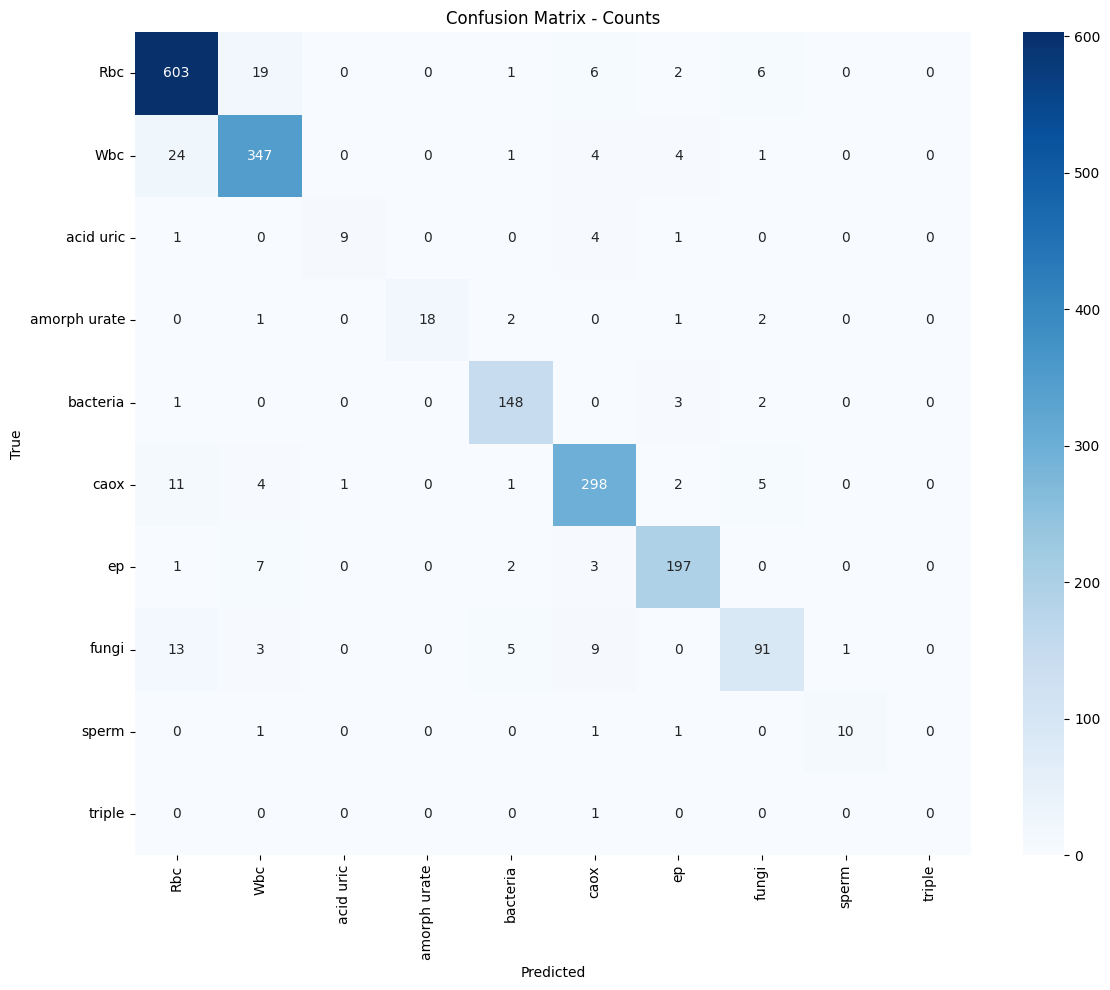

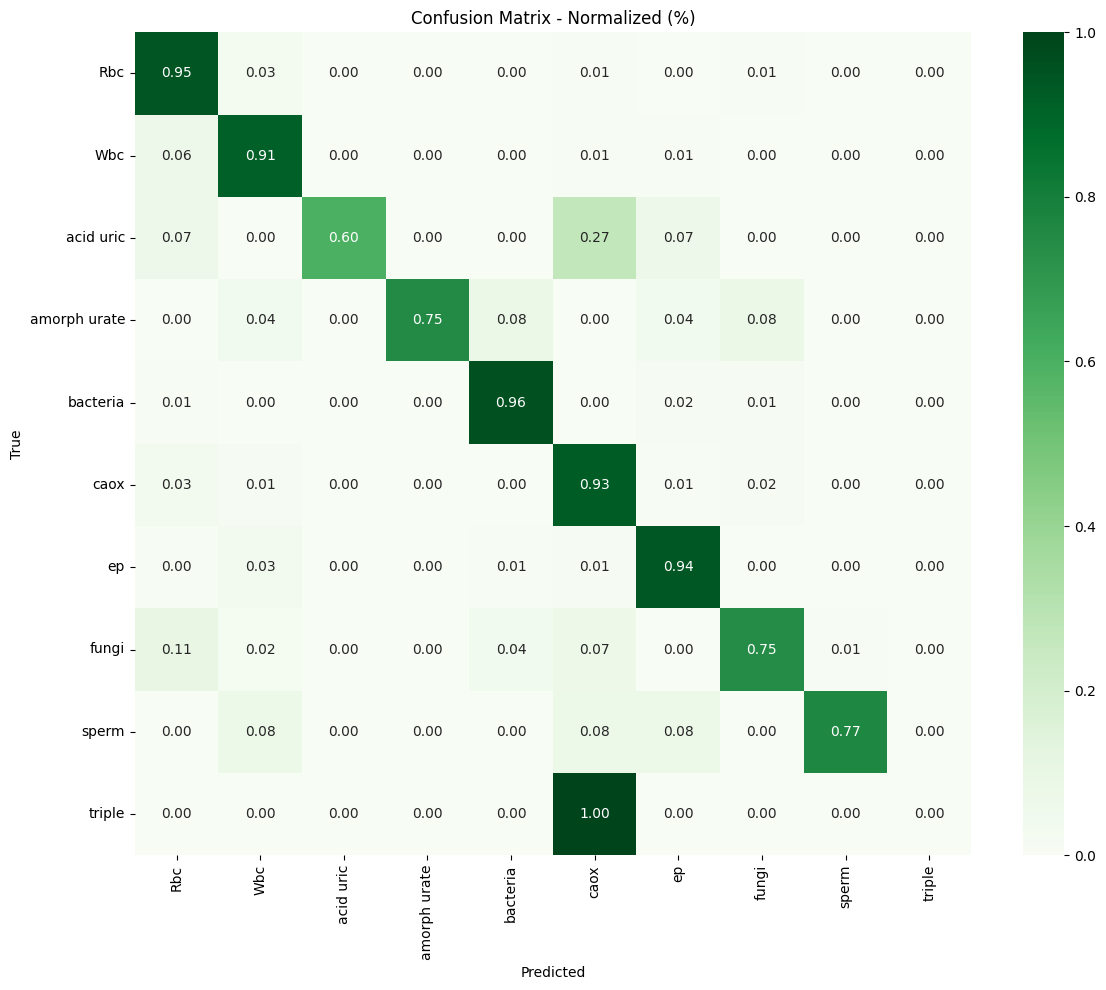

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



====================== CLASSIFICATION REPORT ======================

              precision    recall  f1-score   support

         Rbc     0.9220    0.9466    0.9342       637
         Wbc     0.9084    0.9108    0.9096       381
   acid uric     0.9000    0.6000    0.7200        15
amorph urate     1.0000    0.7500    0.8571        24
    bacteria     0.9250    0.9610    0.9427       154
        caox     0.9141    0.9255    0.9198       322
          ep     0.9336    0.9381    0.9359       210
       fungi     0.8505    0.7459    0.7948       122
       sperm     0.9091    0.7692    0.8333        13
      triple     0.0000    0.0000    0.0000         1

    accuracy                         0.9159      1879
   macro avg     0.8263    0.7547    0.7847      1879
weighted avg     0.9150    0.9159    0.9147      1879


📁 فایل‌ها ذخیره شد در: /content/drive/MyDrive/results_cm


In [7]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os

# -----------------------------
# کلاس‌ها (به ترتیب ImageFolder)
# -----------------------------
class_names = ['Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria',
               'caox', 'ep', 'fungi', 'sperm', 'triple']

save_dir = "/content/drive/MyDrive/results_cm"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# پیش‌بینی روی تست
# -----------------------------
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# -----------------------------
# ساخت Confusion Matrix (خام)
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))

# -----------------------------
# Confusion Matrix نرمال‌شده (درصدی)
# -----------------------------
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, None]
cm_percent = np.nan_to_num(cm_percent)

# -----------------------------
#  رسم و ذخیره CM خام
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Counts")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_counts.png", dpi=300)
plt.show()

# -----------------------------
# رسم و ذخیره CM نرمال‌شده
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Normalized (%)")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_normalized.png", dpi=300)
plt.show()

# -----------------------------
#  گزارش کامل Precision/Recall/F1
# -----------------------------
report = classification_report(
    y_true, y_pred, target_names=class_names, digits=4
)

print("\n====================== CLASSIFICATION REPORT ======================\n")
print(report)

# ذخیره گزارش به فایل TXT
with open(f"{save_dir}/classification_report.txt", "w") as f:
    f.write(report)

print(f"\n📁 فایل‌ها ذخیره شد در: {save_dir}")


In [8]:
# Evaluate the model on the test set
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

test_loss /= total_test
test_accuracy = 100 * correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

torch.save(model.state_dict(), "best_model_test.pth")
print("Model saved successfully!")


Test Loss: 0.4267, Test Accuracy: 91.59%
Model saved successfully!


In [9]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

def evaluate_model_performance(model, test_loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    start_time = time.time()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # زمان پایان
    end_time = time.time()
    calculation_time = end_time - start_time

    # محاسبه معیارها
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # نمایش نتایج
    print("Evaluation Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Calculation Time: {calculation_time:.2f} seconds")



    return accuracy, precision, recall, f1, calculation_time

# فراخوانی تابع برای ارزیابی
classes = ["'Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria', 'caox', 'ep', 'fungi', 'sperm', 'triple'"]  
evaluate_model_performance(model, test_loader, classes)



Evaluation Results:
Accuracy: 0.9159
Precision: 0.9150
Recall (Sensitivity): 0.9159
F1-Score: 0.9147
Calculation Time: 4.67 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.9159127195316658,
 0.9150358761400368,
 0.9159127195316658,
 0.9146539943540116,
 4.67320990562439)

مدل با موفقیت بارگذاری شد.


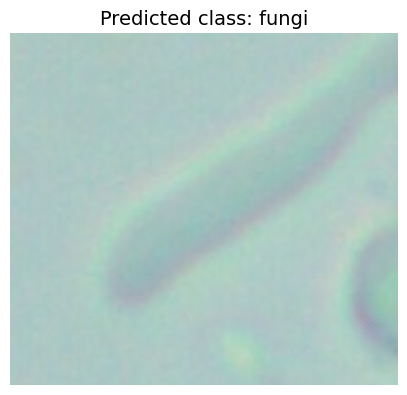

Predicted index: 7
Predicted class: fungi


In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) تعریف مدل مطابق وزن‌های ذخیره‌شده
# --------------------------------------------------
class Net(nn.Module):
    def __init__(self, num_classes=10):
        super(Net, self).__init__()

        # مدل ResNet50 بدون وزن pretrained
        self.resnet = models.resnet50(weights=None)

        # جایگزینی لایه FC اصلی با معماری دلخواه
        self.resnet.fc = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# --------------------------------------------------
# 2) بارگذاری مدل و state_dict با strict=False
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Net(num_classes=10).to(device)

model_path = "/content/drive/MyDrive/best_resnet50_model.pth"
state_dict = torch.load(model_path, map_location=device)

# اضافه کردن prefix 'resnet.' به کلیدها برای تطابق با مدل
new_state_dict = {}
for k, v in state_dict.items():
    new_state_dict['resnet.' + k] = v

# strict=False برای جلوگیری از ارور missing running_mean/running_var
model.load_state_dict(new_state_dict, strict=False)
model.eval()
print("مدل با موفقیت بارگذاری شد.")

# --------------------------------------------------
# 3) نام کلاس‌ها
# --------------------------------------------------
class_names = [
    'Rbc', 'Wbc', 'acid uric', 'amorph urate',
    'bacteria', 'caox', 'ep', 'fungi', 'sperm', 'triple'
]

# --------------------------------------------------
# 4) تابع پیش‌بینی تصویر همراه با نمایش عکس
# --------------------------------------------------
def predict_and_show_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_name = class_names[pred_idx]

    # نمایش تصویر همراه با نام کلاس پیش‌بینی‌شده
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted class: {pred_name}", fontsize=14)
    plt.show()

    return pred_idx, pred_name

# --------------------------------------------------
# 5) اجرای تست
# --------------------------------------------------
test_image = "/content/drive/MyDrive/image with free/fungi/00011.jpg"  
pred_idx, pred_name = predict_and_show_image(test_image)

print("Predicted index:", pred_idx)
print("Predicted class:", pred_name)
